In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

classical_path = Path(r"C:\Users\DANH\Desktop\DS_full\Project_leaves_recognition\reports\metrics_summary.csv")
resnet_path = Path(r"C:\Users\DANH\Desktop\DS_full\Project_leaves_recognition\reports\resnet_metrics.csv")

In [2]:
df_classical = pd.read_csv(classical_path)
df_resnet = pd.read_csv(resnet_path)
df_all = pd.concat([df_classical, df_resnet], ignore_index=True)
df_all = df_all.drop_duplicates(subset=["Model"], keep="last")

df_all.to_csv(classical_path, index=False)
print("Lưu trữ các models ")
display(
    df_all[
        [
            "Model",
            "CV_Accuracy",
            "Test_Accuracy",
            "Macro_F1",
            "Train_Time_Sec",
            "Latency_MS_Per_Img",
        ]
    ]
)

Lưu trữ các models 


,Model,CV_Accuracy,Test_Accuracy,Macro_F1,Train_Time_Sec,Latency_MS_Per_Img
0,SVM (RBF),98.22,97.08,0.9709,289.16,0.34
1,KNN,94.48,93.75,0.9363,7.58,1.93
2,PNN + PCA,94.52,94.58,0.9444,104.10,0.12
3,ResNet-18,99.89,99.58,0.9958,396.15,2.35


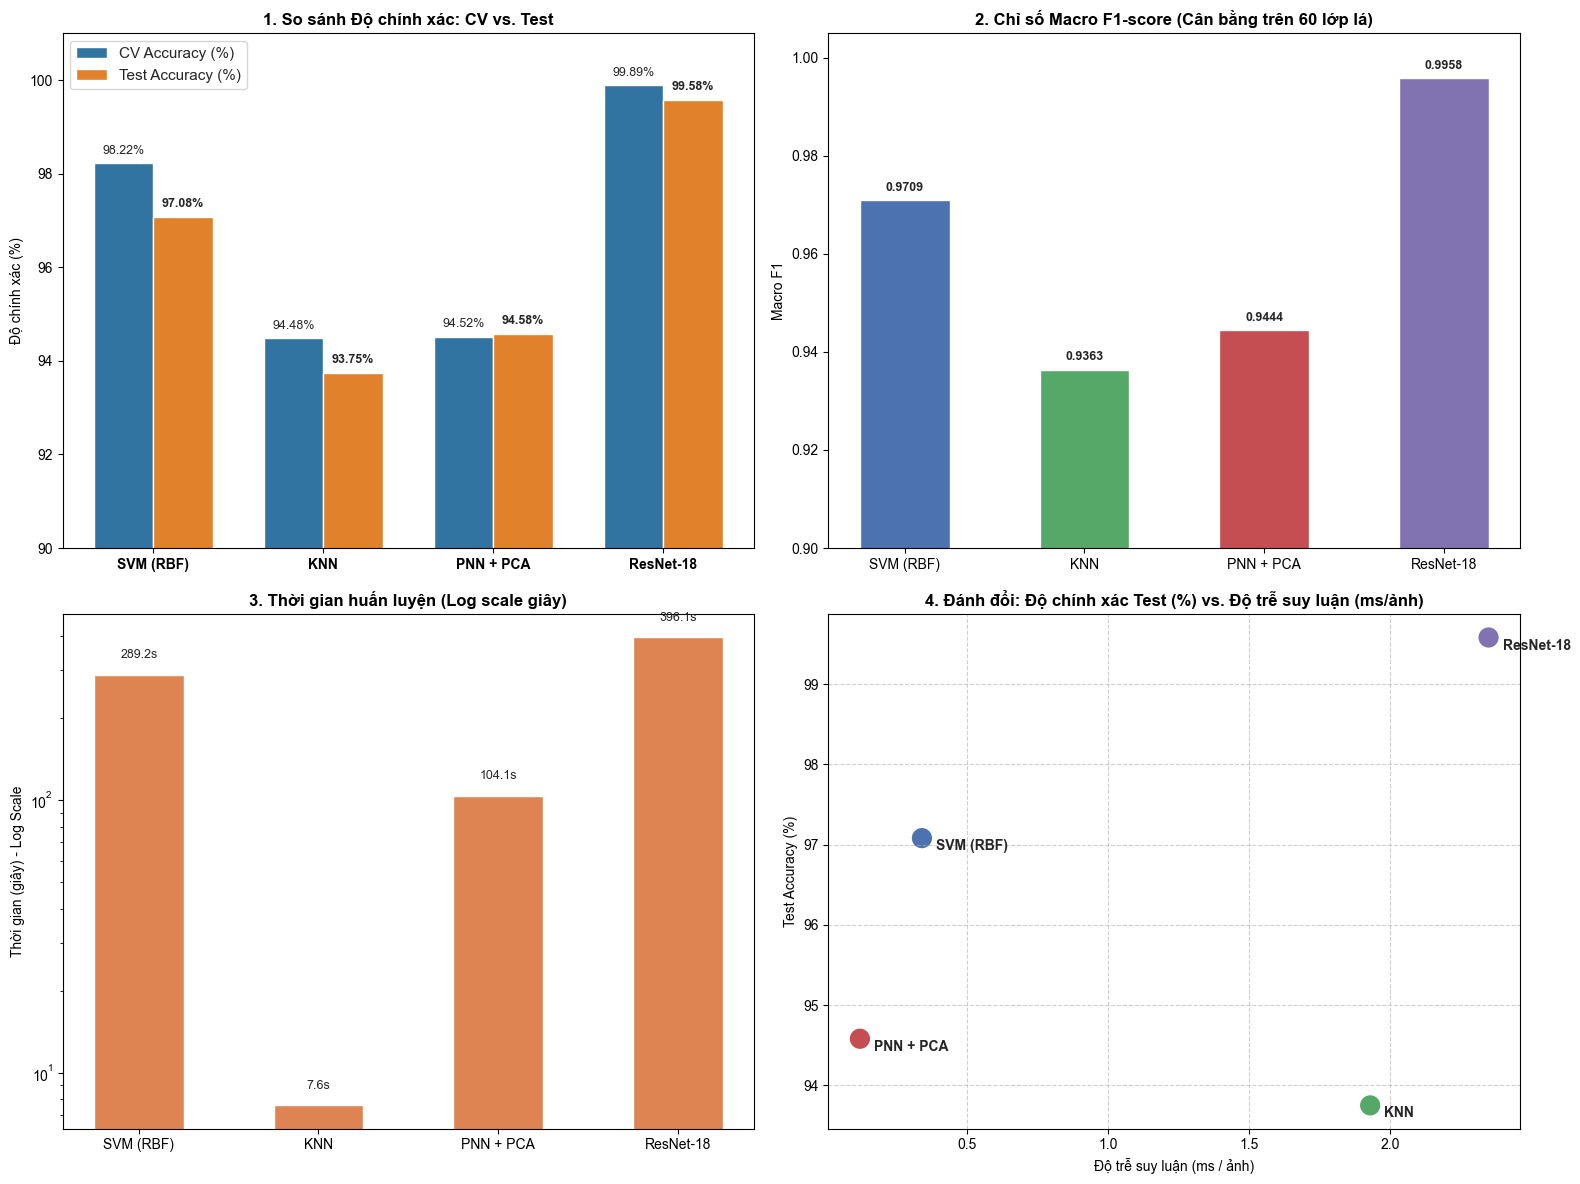

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid", palette="muted")
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Panel 1: Độ chính xác kiểm định chéo vs. Ngoại kiểm (CV vs. Test Accuracy)
x = np.arange(len(df_all["Model"]))
width = 0.35
axes[0, 0].bar(
    x - width / 2,
    df_all["CV_Accuracy"],
    width,
    label="CV Accuracy (%)",
    color="#3274A1",
)
axes[0, 0].bar(
    x + width / 2,
    df_all["Test_Accuracy"],
    width,
    label="Test Accuracy (%)",
    color="#E1812C",
)
axes[0, 0].set_title(
    "1. So sánh Độ chính xác: CV vs. Test", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df_all["Model"], fontsize=10, fontweight="bold")
axes[0, 0].set_ylim(90, 101)
axes[0, 0].set_ylabel("Độ chính xác (%)")
axes[0, 0].legend()
for i in x:
  axes[0, 0].text(
      i - width / 2,
      df_all["CV_Accuracy"].iloc[i] + 0.2,
      f"{df_all['CV_Accuracy'].iloc[i]:.2f}%",
      ha="center",
      fontsize=9,
  )
  axes[0, 0].text(
      i + width / 2,
      df_all["Test_Accuracy"].iloc[i] + 0.2,
      f"{df_all['Test_Accuracy'].iloc[i]:.2f}%",
      ha="center",
      fontsize=9,
      fontweight="bold",
  )

#Điểm Macro F1-score (Độ cân bằng trên 60 lớp)
bars = axes[0, 1].bar(
    df_all["Model"], df_all["Macro_F1"], color=palette, width=0.5
)
axes[0, 1].set_title(
    "2. Chỉ số Macro F1-score (Cân bằng trên 60 lớp lá)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].set_ylim(0.90, 1.005)
axes[0, 1].set_ylabel("Macro F1")
for bar in bars:
  yval = bar.get_height()
  axes[0, 1].text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.002,
      f"{yval:.4f}",
      ha="center",
      fontsize=9,
      fontweight="bold",
  )

#Thời gian huấn luyện (Train Time)
bars_t = axes[1, 0].bar(
    df_all["Model"], df_all["Train_Time_Sec"], color="#DD8452", width=0.5
)
axes[1, 0].set_title(
    "3. Thời gian huấn luyện (Log scale giây)", fontsize=12, fontweight="bold"
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_ylabel("Thời gian (giây) - Log Scale")
for bar in bars_t:
  yval = bar.get_height()
  axes[1, 0].text(
      bar.get_x() + bar.get_width() / 2,
      yval * 1.15,
      f"{yval:.1f}s",
      ha="center",
      fontsize=9,
  )

#Đánh đổi Hiệu năng vs. Độ trễ suy luận (Accuracy vs. Latency)
sns.scatterplot(
    data=df_all,
    x="Latency_MS_Per_Img",
    y="Test_Accuracy",
    hue="Model",
    s=250,
    palette=palette,
    ax=axes[1, 1],
    legend=False,
)
for i in range(len(df_all)):
  axes[1, 1].annotate(
      df_all["Model"].iloc[i],
      (
          df_all["Latency_MS_Per_Img"].iloc[i] + 0.05,
          df_all["Test_Accuracy"].iloc[i] - 0.15,
      ),
      fontsize=10,
      fontweight="bold",
  )
axes[1, 1].set_title(
    "4. Đánh đổi: Độ chính xác Test (%) vs. Độ trễ suy luận (ms/ảnh)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("Độ trễ suy luận (ms / ảnh)")
axes[1, 1].set_ylabel("Test Accuracy (%)")
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**1. Đánh giá tổng quan hiệu năng phân loại**

Nhìn chung, cả bốn mô hình đều thể hiện hiệu năng phân loại ấn tượng trên bộ dữ liệu Foliage 60 loài, với các chỉ số Accuracy và Macro F1-score đều vượt ngưỡng 93%:

ResNet-18 (Deep Learning) dẫn đầu tuyệt đối với Validation Accuracy đạt 99.89% và Test Accuracy ngoại kiểm đạt 99.58% (Macro F1 đạt 0.9958) trên 1.200 ảnh test độc lập. Mô hình thể hiện khả năng khái quát hóa vượt trội, giải quyết triệt để các trường hợp nhầm lẫn giữa các loài có hình thái phức tạp.

SVM (RBF Kernel) là mô hình học máy truyền thống đạt kết quả xuất sắc nhất với CV Accuracy 98.22% và Test Accuracy 97.08% (Macro F1 đạt 0.9709). Việc kết hợp giảm chiều dữ liệu bằng PCA (40 thành phần) và tối ưu hóa siêu tham số ($C=10, \gamma=0.01$) thông qua Grid Search giúp SVM thiết lập được mặt siêu phẳng phân tách phi tuyến tối ưu.

KNN và PNN + PCA đạt hiệu năng tương đương nhau trên cả hai tập đánh giá, dao động quanh mức 93.75% – 94.58% về Test Accuracy. Điểm số Macro F1 đồng đều với Accuracy chứng minh mô hình dự đoán cân bằng trên toàn bộ 60 lớp, không bị thiên lệch bởi kích thước mẫu.

Sự chênh lệch hiệu năng giữa nhóm Machine Learning truyền thống và ResNet-18 bắt nguồn từ phương pháp biểu diễn dữ liệu. Nhóm mô hình truyền thống phụ thuộc vào vector 57 đặc trưng thủ công (hình học, màu sắc, kết cấu Lacunarity, PFT); dù đã tối ưu, các đặc trưng này mang tính nén tĩnh và có thể đánh mất một số chi tiết cấu trúc cục bộ. Ngược lại, ResNet-18 học biểu diễn đặc trưng không gian sâu (deep spatial representations) từ ảnh thô một cách linh hoạt qua các khối dư (Residual Blocks).  

**2. Chi phí huấn luyện và Đánh đổi tài nguyên**
Thời gian huấn luyện giữa các mô hình có sự phân hóa rõ rệt trên biểu đồ :

KNN ghi nhận thời gian huấn luyện ngắn nhất (7.58s): Do bản chất là thuật toán học lười (lazy learning), chi phí tính toán trong pha huấn luyện chủ yếu tập trung vào việc ước lượng ma trận hiệp phương sai và biến đổi không gian bằng PCA.

PNN + PCA đứng thứ hai về tốc độ (104.10s): Mạng nơ-ron xác suất thiết lập trọng số chỉ qua một lượt nạp dữ liệu vào tầng mẫu (pattern layer), thời gian thực thi chủ yếu dành cho bước tìm kiếm tham số độ mịn $\sigma$ và số chiều PCA tối ưu.

SVM (RBF) tiêu tốn 289.16s: Quá trình tìm kiếm lưới (Grid Search) kết hợp kiểm định chéo K-fold trên không gian siêu tham số đòi hỏi giải nhiều bài toán tối ưu lồi bậc hai liên tiếp.

ResNet-18 có thời gian huấn luyện dài nhất (396.15s trên GPU): Đây là sự đánh đổi tất yếu để tối ưu hóa hàng triệu trọng số thông qua thuật toán AdamW và bộ lập lịch Cosine Annealing qua 15 epochs.


**Độ trễ suy luận và Khả năng triển khai thực tế**
Khảo sát thời gian suy luận trên từng ảnh (Latency_MS_Per_Img) mang lại góc nhìn thực tế cho bài toán triển khai hệ thống:

PNN + PCA tối ưu nhất cho bài toán thời gian thực: Đạt độ trễ suy luận thấp kỷ lục chỉ 0.12 ms/ảnh (0.14s cho toàn bộ 1.200 ảnh test) nhờ cơ chế tính toán ma trận mật độ xác suất một chiều, là ứng viên lý tưởng cho các thiết bị phần cứng nhúng hạn chế tài nguyên.

SVM (RBF) đạt độ cân bằng cao nhất: Duy trì độ trễ chỉ 0.34 ms/ảnh trong khi vẫn đảm bảo độ chính xác vượt trội trên 97%.

KNN có độ trễ suy luận cao (1.93 ms/ảnh): Mặc dù huấn luyện tức thì, pha dự đoán của KNN chậm hơn SVM gần 6 lần do phải tính toán khoảng cách Euclidean giữa vector truy vấn tới toàn bộ tập dữ liệu mẫu trong không gian 57 chiều.

ResNet-18 có độ trễ 2.35 ms/ảnh: Tương đương khả năng xử lý đạt xấp xỉ 425 khung hình/giây (FPS) trên GPU, hoàn toàn đáp ứng tốt các ứng dụng nhận diện thực vật thời gian thực qua camera giám sát.